Use virtual environment's python interpreter to run the notebook


In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.float_format', lambda x: f'{x:.128f}')



In [2]:
df32 = pd.read_csv("data32_disruption_warning_table.csv").sort_values(['shot', 'time']).astype(np.float128, errors='ignore')
df64 = pd.read_csv("data64_disruption_warning_table.csv").sort_values(['shot', 'time']).astype(np.float128, errors='ignore')
dataNone = pd.read_csv("dataNone_disruption_warning_table.csv").sort_values(['shot', 'time']).astype(np.float128, errors='ignore')

In [3]:
df32['tau'] = df32['wmhd'] / (df32['p_input'] - df32['dwmhd_dt'])
df64['tau'] = df64['wmhd'] / (df64['p_input'] - df64['dwmhd_dt'])
dataNone['tau'] = dataNone['wmhd'] / (dataNone['p_input'] - dataNone['dwmhd_dt'])

In [4]:
(df32.shot.nunique(),
df64.shot.nunique(),
dataNone.shot.nunique())

(10429, 10429, 10429)

In [5]:
(df32.shape,
df64.shape,
dataNone.shape)

((940543, 65), (940543, 65), (940543, 65))

In [6]:
def count_infinity(df):
    pos_inf = np.isposinf(df.values).sum()
    neg_inf = np.isneginf(df.values).sum()
    return {'+inf': pos_inf, '-inf': neg_inf, 'total': pos_inf + neg_inf}

print("df32:", count_infinity(df32))
print("df64:", count_infinity(df64))
print("dataNone:", count_infinity(dataNone))

df32: {'+inf': np.int64(0), '-inf': np.int64(1), 'total': np.int64(1)}
df64: {'+inf': np.int64(0), '-inf': np.int64(1), 'total': np.int64(1)}
dataNone: {'+inf': np.int64(0), '-inf': np.int64(1), 'total': np.int64(1)}


In [7]:
# Find columns in df64 that contain positive or negative infinity
inf_columns = df64.columns[(np.isposinf(df64.values).any(axis=0)) | (np.isneginf(df64.values).any(axis=0))]
print("Columns containing infinity values:", inf_columns.tolist())

Columns containing infinity values: ['radiated_fraction']


That should have been the end of the universe, yet here we are.

In [8]:
# get shot numbers with infinity values
inf_shots_32 = df32[df32['radiated_fraction'].isin([np.inf, -np.inf])]['shot'].unique()
inf_shots_64 = df64[df64['radiated_fraction'].isin([np.inf, -np.inf])]['shot'].unique()
inf_shots_none = dataNone[dataNone['radiated_fraction'].isin([np.inf, -np.inf])]['shot'].unique()


Shot 1120215020.0, Time 1.459999918937683: -inf


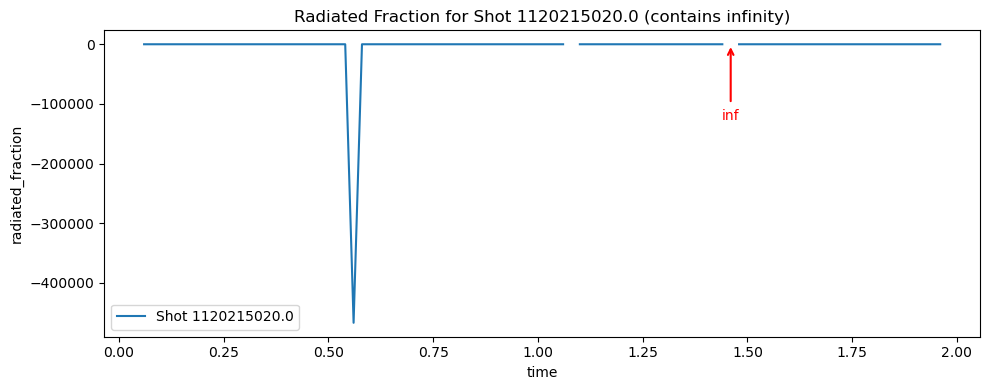

In [9]:
import matplotlib.pyplot as plt
for shot in inf_shots_64:
    df_shot = df64[df64['shot'] == shot]
    plt.figure(figsize=(10, 4))
    plt.plot(df_shot['time'], df_shot['radiated_fraction'], label=f'Shot {shot}')
    # annotate the infinity points
    inf_points = df_shot[df_shot['radiated_fraction'].isin([np.inf, -np.inf])]
    for _, row in inf_points.iterrows():
        print(f"Shot {shot}, Time {row['time']}: {row['radiated_fraction']}")
        plt.annotate('inf', (row['time'], -150000), textcoords="offset points", xytext=(0,10), ha='center', color='red')
        # arrow to the point
        plt.annotate('', xy=(row['time'], 0), xytext=(row['time'], -100000),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    plt.xlabel('time')
    plt.ylabel('radiated_fraction')
    plt.title(f'Radiated Fraction for Shot {shot} (contains infinity)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    

In [10]:
df_shot.columns

Index(['idx', 'shot', 'time', 'a_minor', 'beta_n', 'beta_p', 'bt', 'chisq',
       'dbetap_dt', 'dip_dt', 'dip_smoothed', 'dipprog_dt', 'dli_dt', 'dn_dt',
       'dprad_dt', 'dwmhd_dt', 'greenwald_fraction', 'i_efc', 'ip', 'ip_error',
       'ip_prog', 'kappa', 'kappa_area', 'li', 'lower_gap', 'n_e',
       'n_equal_1_mode', 'n_equal_1_normalized', 'n_equal_1_phase',
       'n_over_ncrit', 'ne_peaking', 'p_icrf', 'p_input', 'p_lh', 'p_oh',
       'p_rad', 'prad_peaking', 'pressure_peaking', 'q0', 'q95', 'qstar',
       'radiated_fraction', 'rmagx', 'ssep', 'sxr', 'tau_rad',
       'te_core_vs_avg_ece', 'te_edge_vs_avg_ece', 'te_peaking', 'te_width',
       'te_width_ece', 'time_until_disrupt', 'tribot', 'tritop', 'upper_gap',
       'v_loop', 'v_loop_efit', 'v_surf', 'v_z', 'wmhd', 'z_error', 'z_prog',
       'z_times_v_z', 'zcur', 'tau'],
      dtype='object')

Radiatied fraction formula

$$
\text{Radiated Fraction} = \frac{P_{\text{rad}}}{P_{\text{input}}}
$$

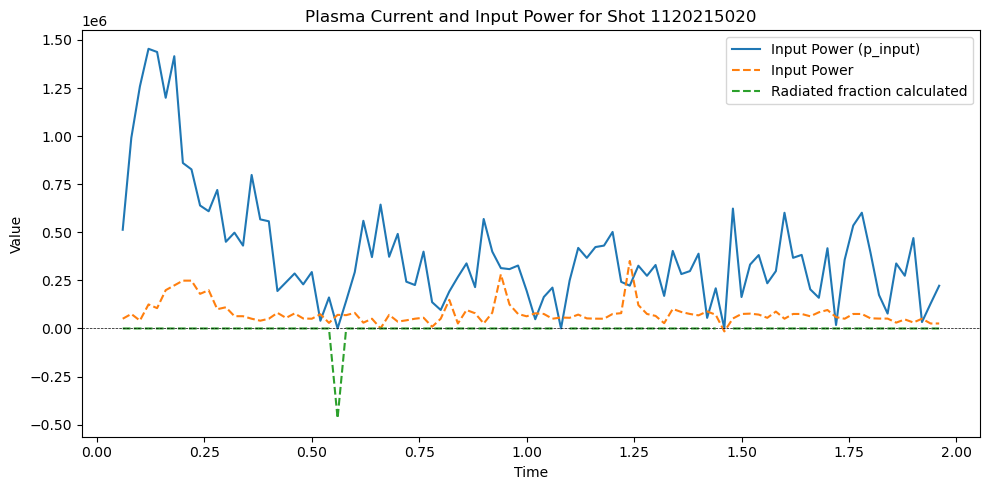

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# plt.plot(df_shot['time'], df_shot['ip'], label='Plasma Current (ip)')
plt.plot(df_shot['time'], df_shot['p_input'], label='Input Power (p_input)')
# plt.plot(df_shot['time'], df_shot['wmhd'], label='Wmhd', linestyle='--')
plt.plot(df_shot['time'], df_shot['p_rad'], label='Input Power ', linestyle='--')
plt.plot(df_shot['time'], df_shot['p_rad']/df_shot['p_input'], label='Radiated fraction calculated', linestyle='--')
# plt.plot(df_shot['time'], df_shot['dwmhd_dt'], label='dwmhd_dt', linestyle='--')
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Plasma Current and Input Power for Shot 1120215020')
plt.legend()
plt.tight_layout()
plt.show()

Input power 0 -> divergence

In [12]:
df32.replace([np.inf, -np.inf], np.nan, inplace=True)
df64.replace([np.inf, -np.inf], np.nan, inplace=True)
dataNone.replace([np.inf, -np.inf], np.nan, inplace=True)

In [13]:
print("df32:", count_infinity(df32))
print("df64:", count_infinity(df64))
print("dataNone:", count_infinity(dataNone))

df32: {'+inf': np.int64(0), '-inf': np.int64(0), 'total': np.int64(0)}
df64: {'+inf': np.int64(0), '-inf': np.int64(0), 'total': np.int64(0)}
dataNone: {'+inf': np.int64(0), '-inf': np.int64(0), 'total': np.int64(0)}


In [14]:
nan_count_df64 = df64.isna().sum().sum()
nan_count_df32 = df32.isna().sum().sum()
nan_count_dataNone = dataNone.isna().sum().sum()
print(f"Total NaN values in df64: {nan_count_df64}")
print(f"Total NaN values in df32: {nan_count_df32}")
print(f"Total NaN values in dataNone: {nan_count_dataNone}")

Total NaN values in df64: 4135015
Total NaN values in df32: 4135008
Total NaN values in dataNone: 4135008


There are less NaN values in df32 compared to df64 

In [16]:

# Get all unique shots
shots = df32.shot.unique()

# Store results
nan_diff_report = []

for shot in shots:
    df32_shot = df32[df32.shot == shot]
    df64_shot = df64[df64.shot == shot]
    dataNone_shot = dataNone[dataNone.shot == shot]
    
    for col in df32.columns:
        nan_count_32 = df32_shot[col].isna().sum()
        nan_count_64 = df64_shot[col].isna().sum()
        nan_count_none = dataNone_shot[col].isna().sum()
        
        if (nan_count_32 != nan_count_64) or (nan_count_32 != nan_count_none) or (nan_count_64 != nan_count_none):
            nan_diff_report.append({
                'shot': shot,
                'variable': col,
                'df32_nan': nan_count_32,
                'df64_nan': nan_count_64,
                'dataNone_nan': nan_count_none
            })

# Convert to DataFrame for easier viewing
nan_diff_df = pd.DataFrame(nan_diff_report)
nan_diff_df

,shot,variable,df32_nan,df64_nan,dataNone_nan
0,1050620004.000000000000000000000000000000000000...,pressure_peaking,77,76,77
1,1120207015.000000000000000000000000000000000000...,te_width,1,0,1
2,1120221031.000000000000000000000000000000000000...,radiated_fraction,0,1,0
3,1120720021.000000000000000000000000000000000000...,prad_peaking,3,4,3
4,1120731024.000000000000000000000000000000000000...,prad_peaking,3,4,3
5,1120821029.000000000000000000000000000000000000...,prad_peaking,3,4,3
6,1120917009.000000000000000000000000000000000000...,prad_peaking,4,5,4
7,1140402012.000000000000000000000000000000000000...,prad_peaking,5,6,5
8,1140403023.000000000000000000000000000000000000...,te_width,15,13,15
9,1140821002.000000000000000000000000000000000000...,prad_peaking,2,3,2


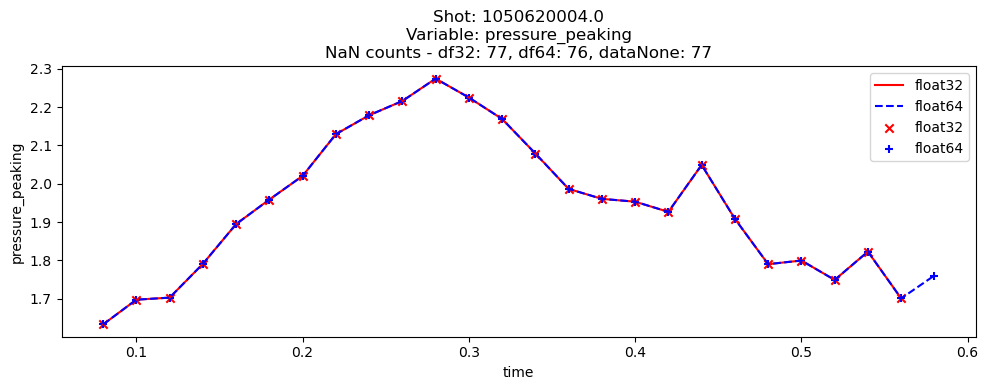

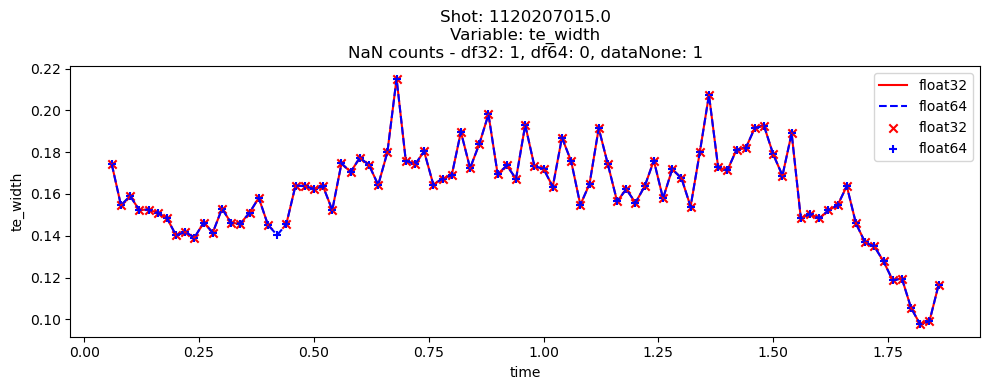

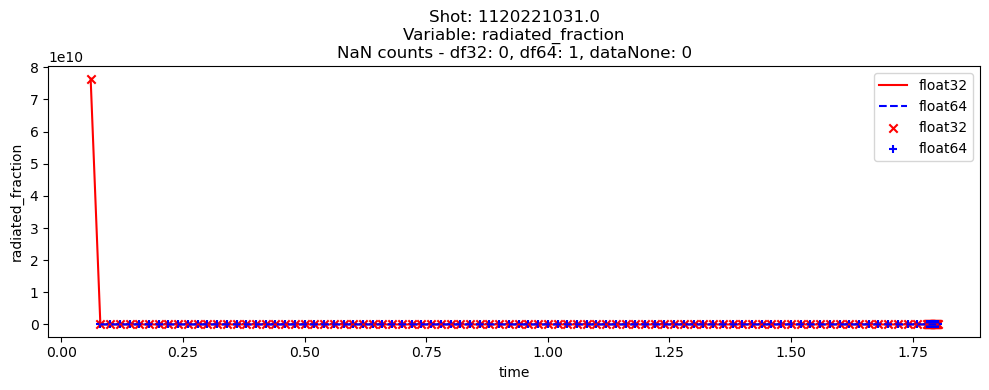

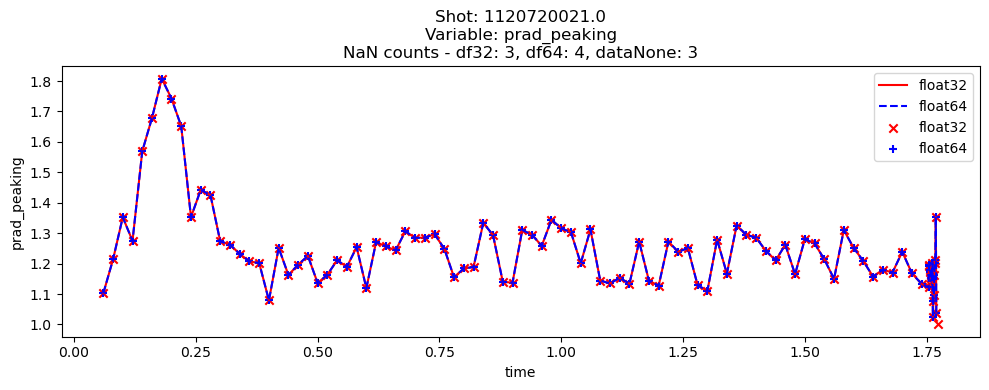

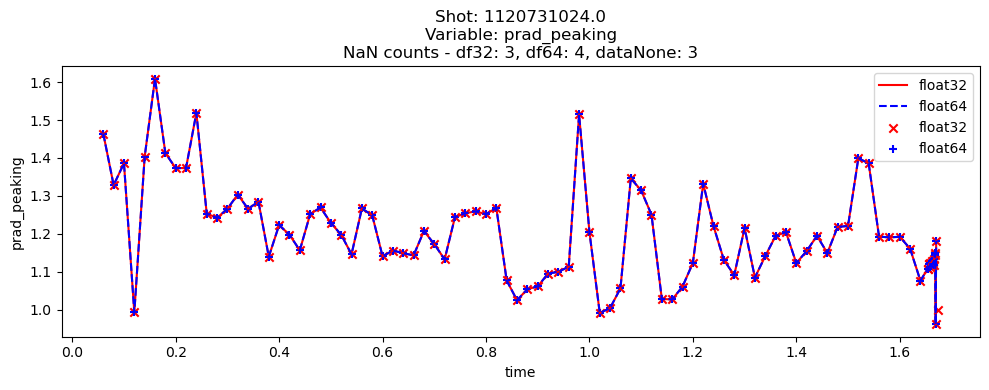

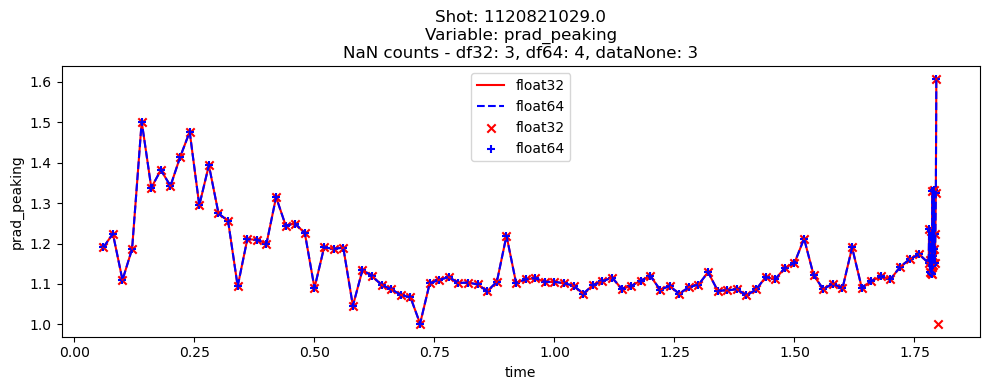

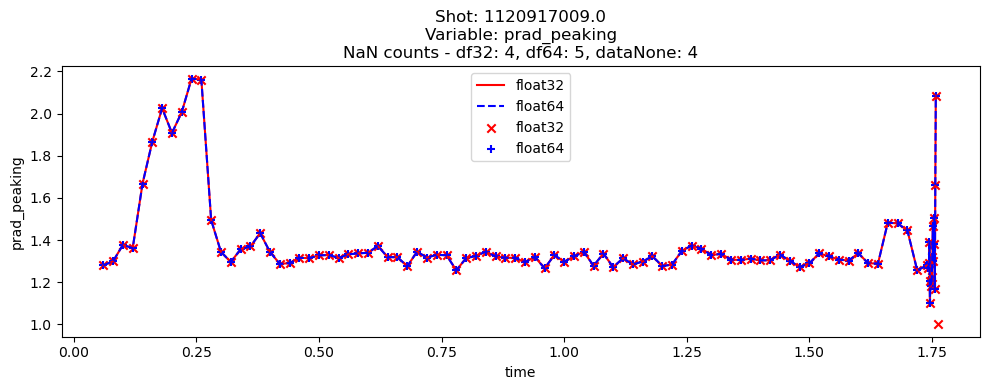

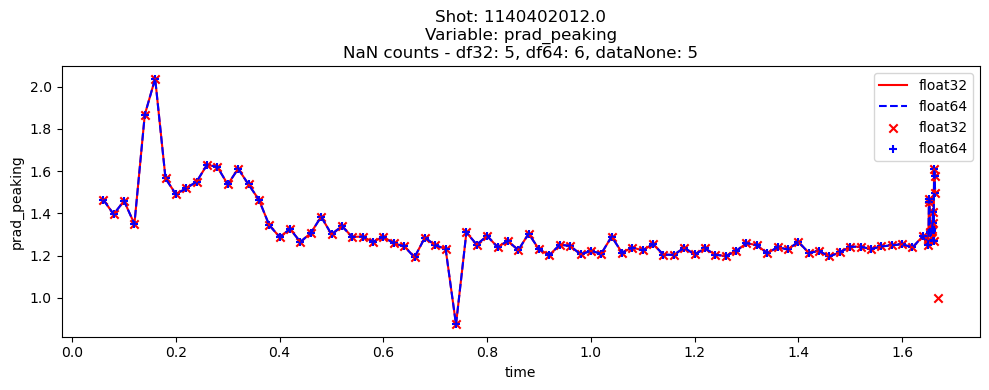

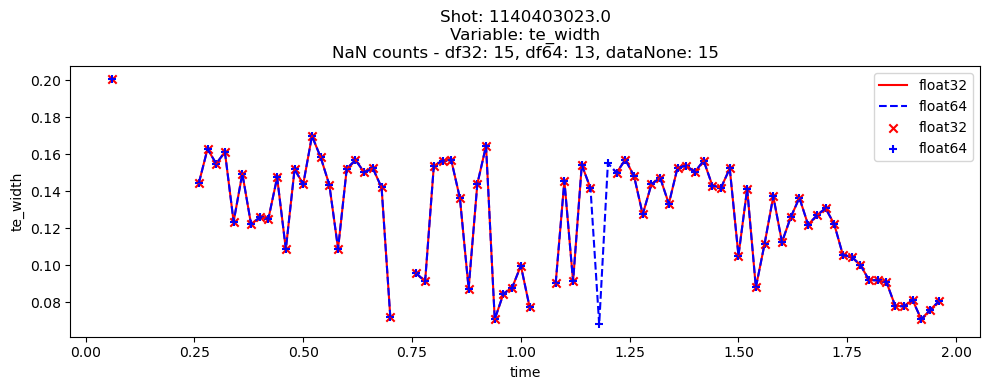

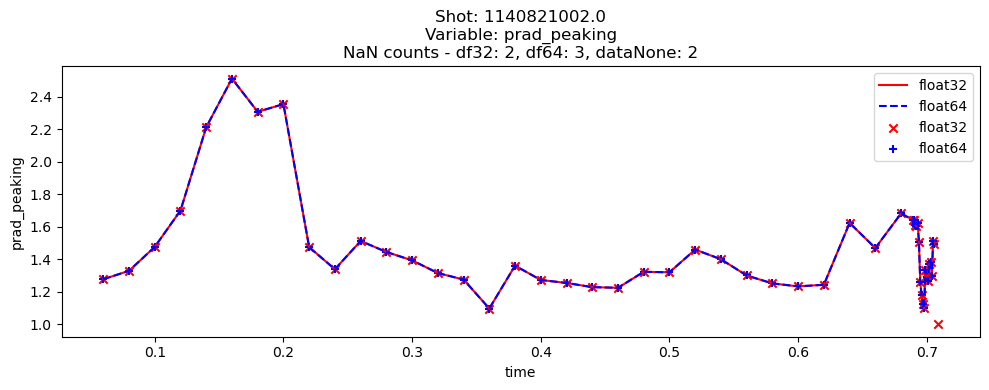

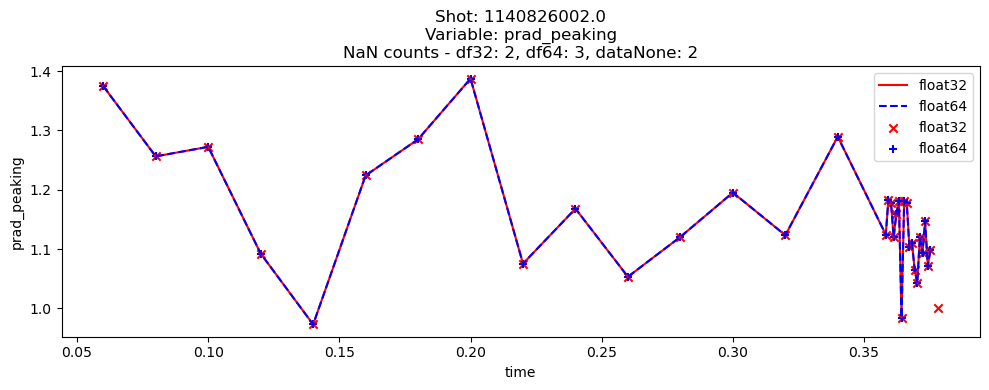

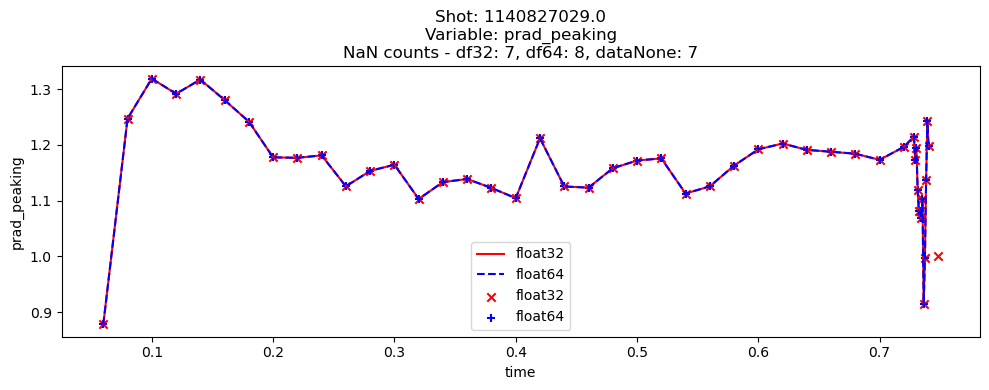

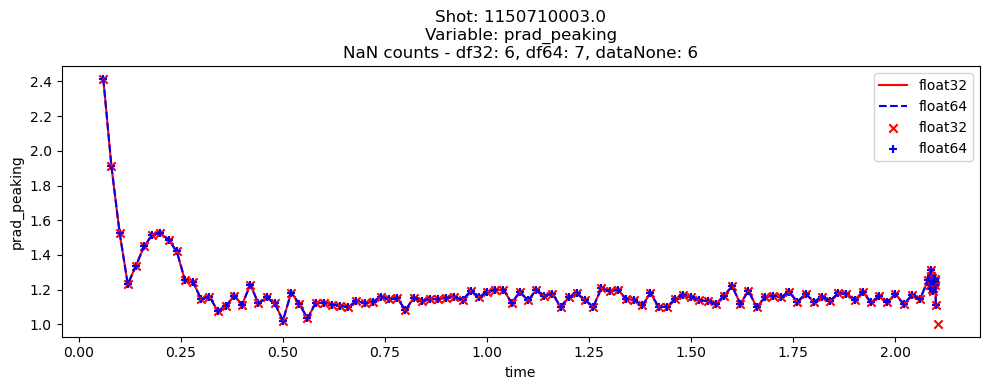

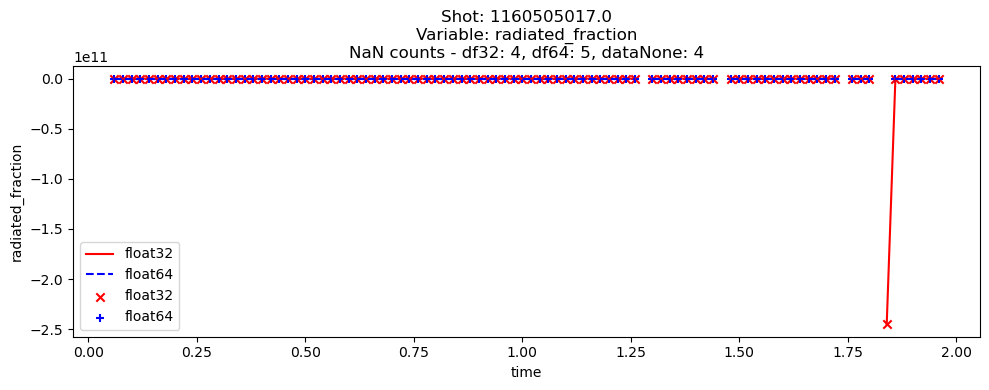

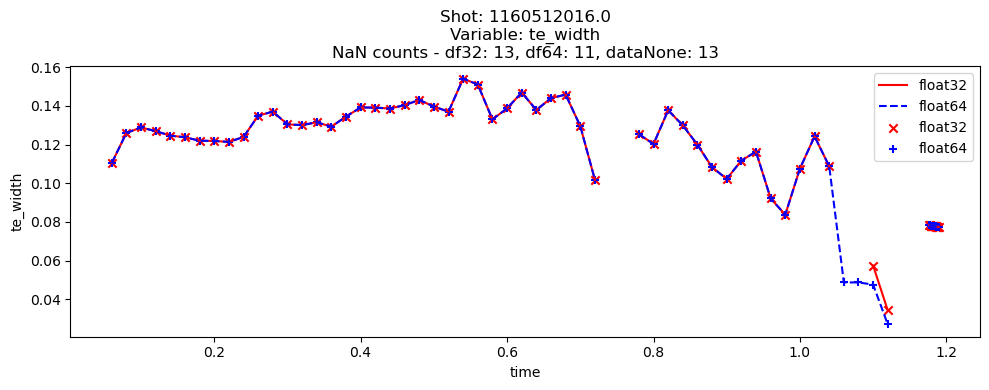

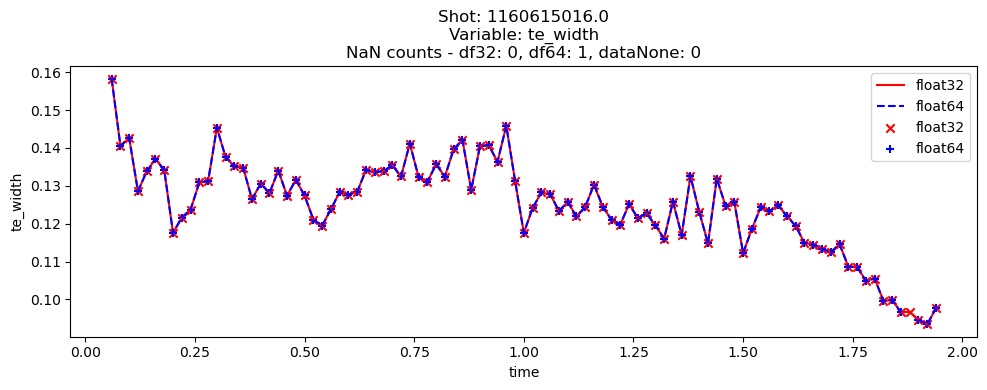

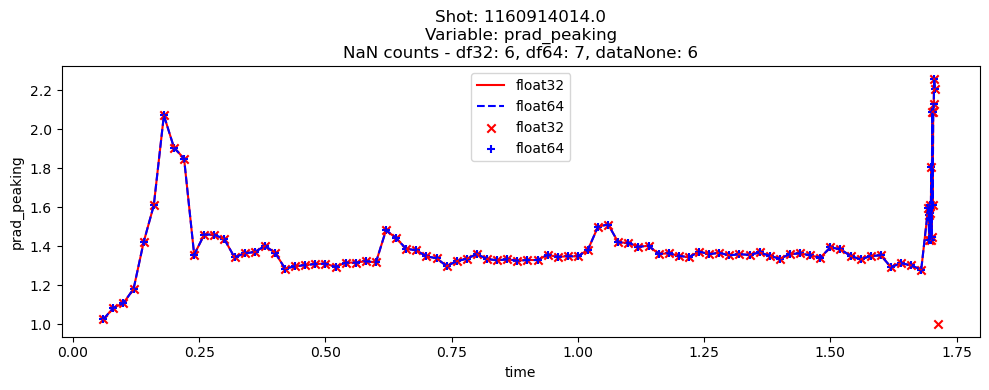

In [32]:
import matplotlib.pyplot as plt

for idx, row in nan_diff_df.iterrows():
    shot = row['shot']
    variable = row['variable']
    df32_shot = df32[df32['shot'] == shot]
    df64_shot = df64[df64['shot'] == shot]
    if variable not in df32_shot.columns or variable not in df64_shot.columns:
        continue
    plt.figure(figsize=(10, 4))
    plt.plot(df32_shot['time'], df32_shot[variable], label='float32', color='r')
    plt.plot(df64_shot['time'], df64_shot[variable], label='float64', color='b', linestyle='--')
    plt.scatter(df32_shot['time'], df32_shot[variable], label='float32', color='r', marker='x')
    plt.scatter(df64_shot['time'], df64_shot[variable], label='float64', color='b', marker='+')
    plt.title(f"Shot: {shot}\nVariable: {variable}\nNaN counts - df32: {row['df32_nan']}, df64: {row['df64_nan']}, dataNone: {row['dataNone_nan']}")
    plt.xlabel('time')
    plt.ylabel(variable)
    plt.legend()
    plt.tight_layout()
    plt.show()

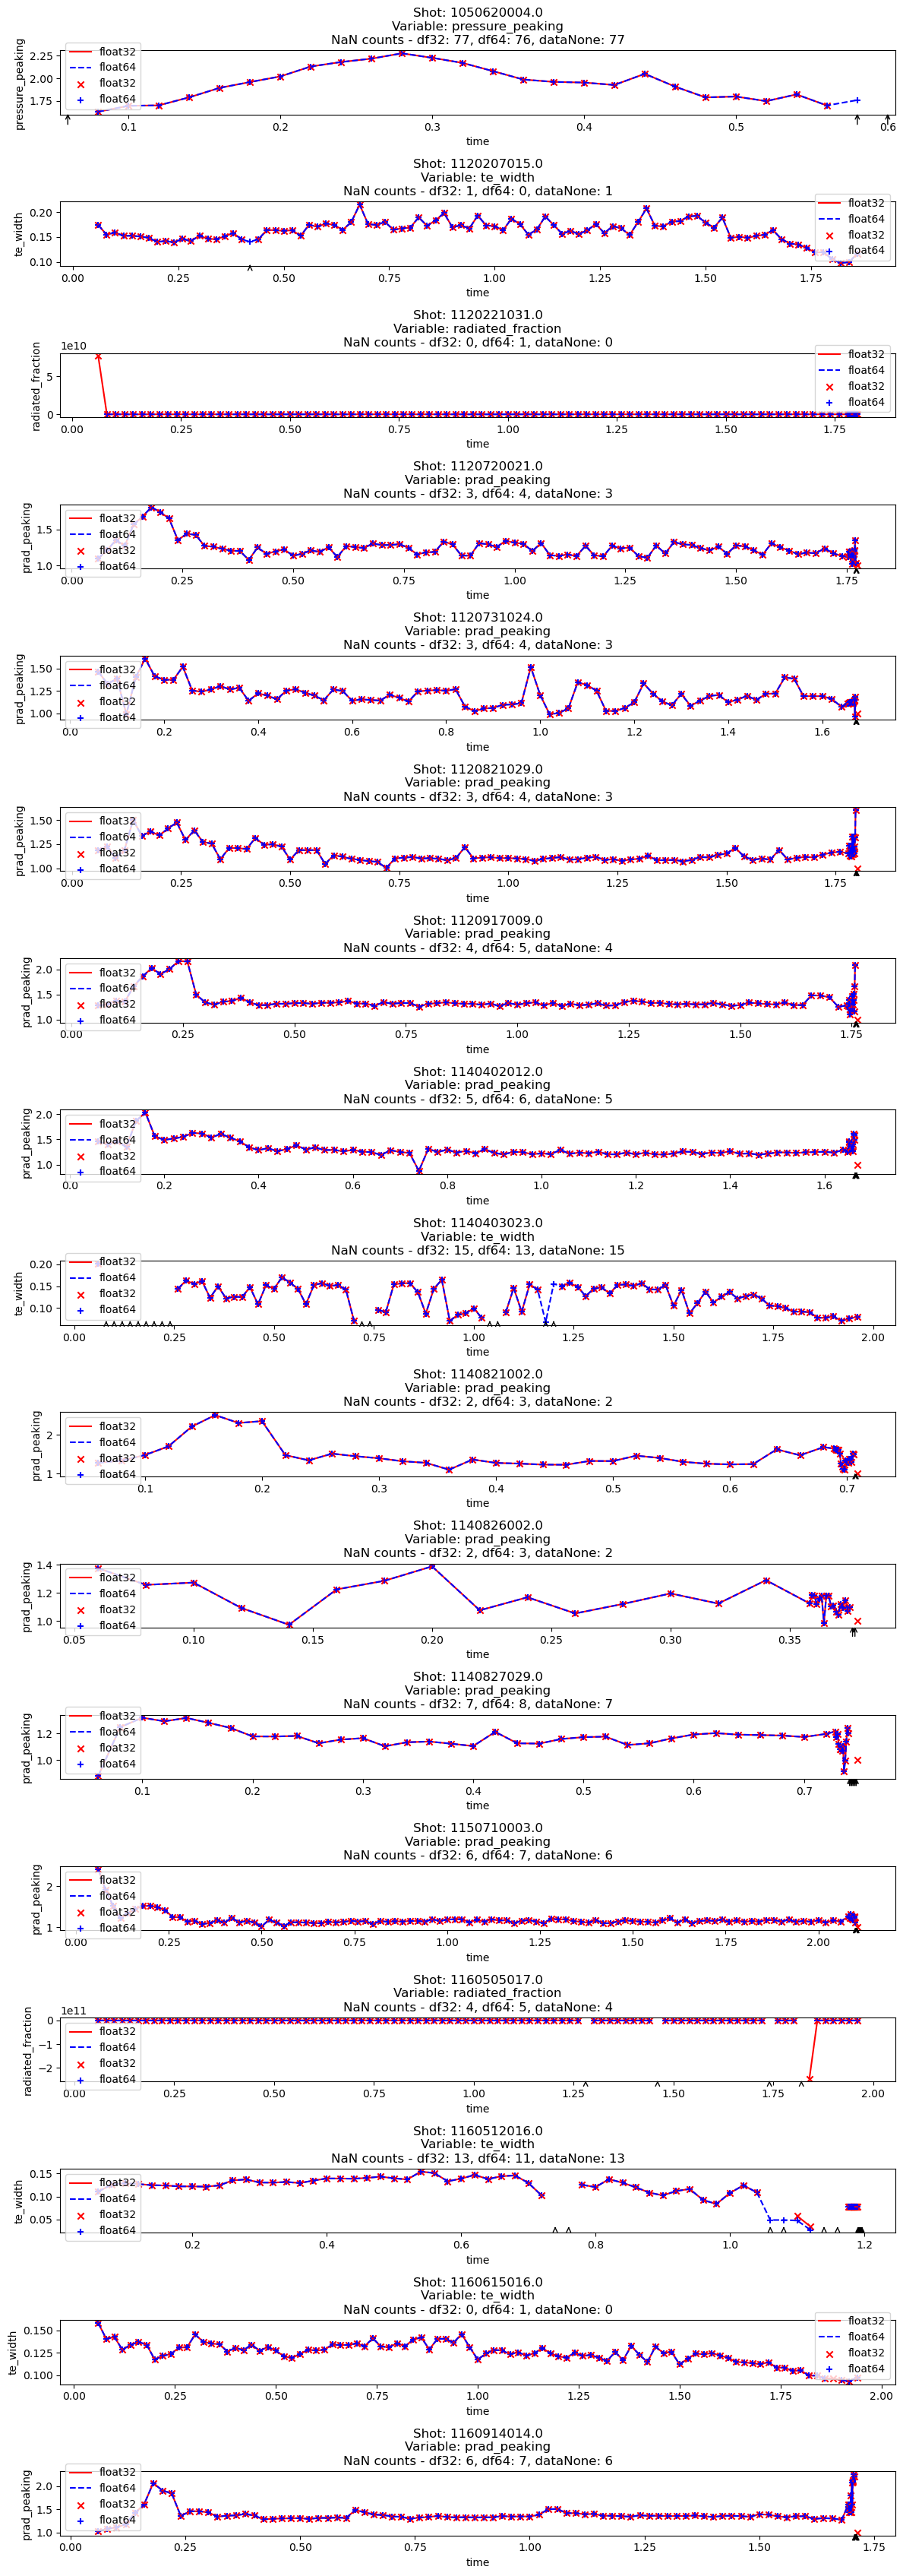

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(nan_diff_df),1, figsize=(12, 2 * len(nan_diff_df)))
for idx, row in nan_diff_df.iterrows():
    shot = row['shot']
    variable = row['variable']
    df32_shot = df32[df32['shot'] == shot]
    df64_shot = df64[df64['shot'] == shot]
    if variable not in df32_shot.columns or variable not in df64_shot.columns:
        continue

    ax[idx].plot(df32_shot['time'], df32_shot[variable], label='float32', color='r')
    ax[idx].plot(df64_shot['time'], df64_shot[variable], label='float64', color='b', linestyle='--')
    ax[idx].scatter(df32_shot['time'], df32_shot[variable], label='float32', color='r', marker='x')
    ax[idx].scatter(df64_shot['time'], df64_shot[variable], label='float64', color='b', marker='+')
    # Mark arrows pointing to NaN positions in df32_shot[variable]
    nan_mask = df32_shot[variable].isna()
    if nan_mask.any():
        nan_times = df32_shot['time'][nan_mask]
        nan_vals = np.full(nan_times.shape, np.nanmin(df32_shot[variable]))
        for t, v in zip(nan_times, nan_vals):
            ax[idx].annotate('', xy=(t, v), xytext=(t, v - 0.1 * abs(v) if v != 0 else -0.1),
                             arrowprops=dict(facecolor='black', arrowstyle='->'), color='purple')
            # ax[idx].annotate('NaN', xy=(t, v), xytext=(t, v - 0.1 * abs(v) if v != 0 else -0.1),
            #                  arrowprops=dict(facecolor='black', arrowstyle='->'), color='purple')
    ax[idx].set_title(f"Shot: {shot}\nVariable: {variable}\nNaN counts - df32: {row['df32_nan']}, df64: {row['df64_nan']}, dataNone: {row['dataNone_nan']}")
    ax[idx].set_xlabel('time')
    ax[idx].set_ylabel(variable)
    ax[idx].legend()
    plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt

# Select first shot
shot = nan_diff_df.shot.unique()[10]

# Precompute NaN masks
isna32 = df32[df32.shot == shot].isna().values
isna64 = df64[df64.shot == shot].isna().values
isnaNone = dataNone[dataNone.shot == shot].isna().values



In [18]:
df32[df32.shot == shot].isna().head()

,idx,shot,time,a_minor,beta_n,beta_p,bt,chisq,dbetap_dt,dip_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,tau
806485,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
806486,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
806487,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
806488,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
806489,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


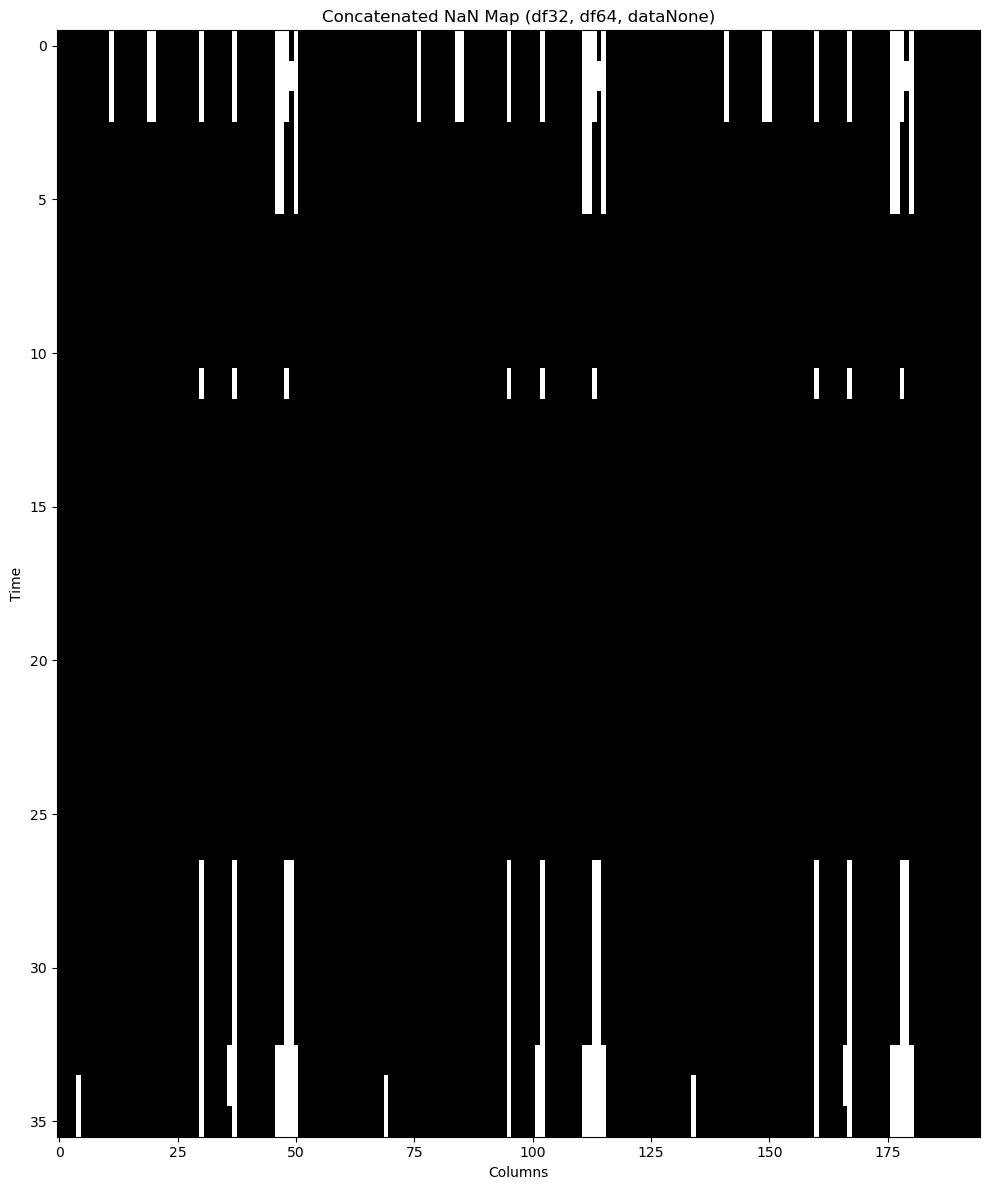

In [19]:
# Concatenate the NaN masks vertically for comparison
isna_concat = np.concatenate([isna32, isna64, isnaNone], axis=1)

# Visualize the concatenated NaN mask
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(isna_concat, aspect='auto', interpolation='none', cmap='gray')
ax.set_title('Concatenated NaN Map (df32, df64, dataNone)')
ax.set_xlabel('Columns')
ax.set_ylabel('Time')
# ax.set_xticks([])
# ax.set_yticks([])
plt.tight_layout()
plt.show()
